In [2]:
%pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-pypi-packag

Processing strike 9750 from column 'R_9750'
             iv         m     TTE     K
0      0.007933 -0.016559  7.9999  9750
1      0.007996 -0.016714  7.9998  9750
2      0.008010 -0.016749  7.9997  9750
3      0.007926 -0.016542  7.9996  9750
4      0.008275 -0.016524  7.9995  9750
...         ...       ...     ...   ...
22318  0.008390 -0.016950  5.0098  9750
22319  0.008135 -0.016338  5.0057  9750
22320  0.008146 -0.016364  5.0033  9750
22321  0.007991 -0.015993  5.0005  9750
22322  0.007991 -0.015994  5.0001  9750

[22323 rows x 4 columns]
Polynomial coefficients: 15.402559097445451, 0.23023136292459062, 0.007719341058955909


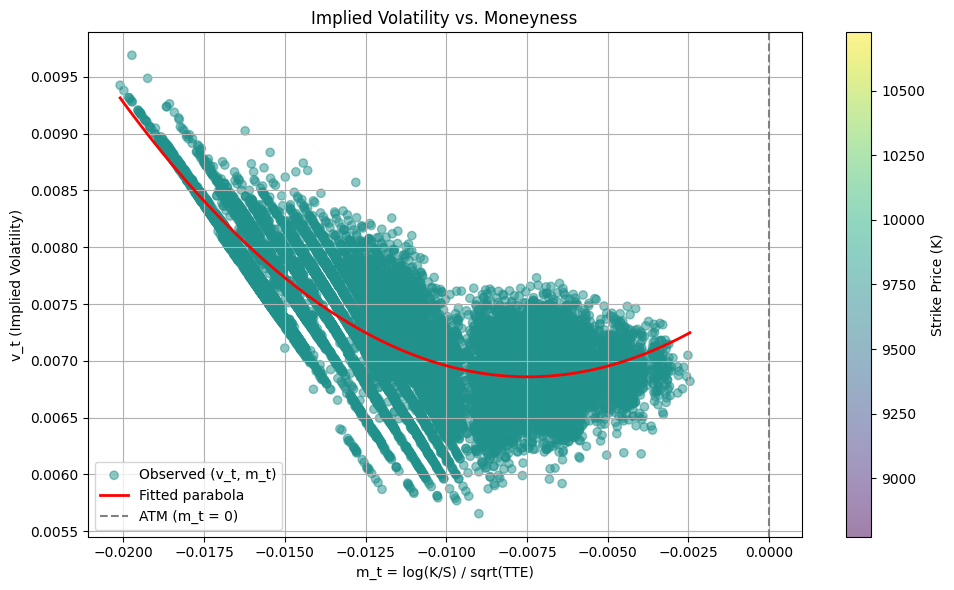

In [31]:
'''
r3_df = pd.concat(
    [
        pd.read_csv(f"..\\data\\round3\\prices_round_3_day_{i}.csv", sep=';')
        .assign(timestamp=lambda df: (i * 1_000_000 + df['timestamp']))
        for i in range(3)
    ],
    ignore_index=True
)
'''

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import re

r5_df = pd.concat(
    [
        pd.read_csv(f"..\\data\\round5\\prices_round_5_day_{i+2}.csv", sep=';')
        .assign(timestamp=lambda df: (i * 1_000_000 + df['timestamp']))
        for i in range(3)
    ],
    ignore_index=True
)


# get all columns that start with "VOLCANIC_ROCK" <-- CHANGE THIS TO YOUR PRODUCT
rock_df = r5_df[r5_df['product'].isin(["VOLCANIC_ROCK_VOUCHER_9750", "VOLCANIC_ROCK"])].copy()

'''
rock_df = r3_df[r3_df['product'].str.startswith("VOLCANIC_ROCK")].copy()
extra_rock_df = r4_df[r4_df['product'].str.startswith("VOLCANIC_ROCK")].copy()
frames = [rock_df, extra_rock_df]
rock_df = pd.concat(frames)
'''

def TTE(timestamp):
    return 8 - timestamp/1000000

rock_df["TTE"] = rock_df["timestamp"].apply(TTE)
# rock_df

pivot = rock_df.pivot(index='TTE',
                    columns='product',
                    values='mid_price')
pivot.columns = pivot.columns.str.replace('VOLCANIC_ROCK_VOUCHE', '') 
pivot = pivot.reset_index()
pivot = pivot.sort_values(by='TTE', ascending=False)
# pivot

strike_cols = [col for col in pivot.columns if col.startswith('R')]
strikes = [int(col.split('_')[1]) for col in strike_cols]

for K in strikes:
    pivot[f'm_{K}'] = np.log(K / pivot["VOLCANIC_ROCK"]) / np.sqrt(pivot["TTE"])
# pivot

def norm_cdf(x):
    return 0.5 * (1 + math.erf(x / math.sqrt(2)))

def BSM(S, K, T, sigma):
    """Black-Scholes on European calls."""
    d1 = (np.log(S / K) + (0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm_cdf(d1) - K * norm_cdf(d2)

# find sigma that gives price = 
def iv(S, K, T, price, max_iter=100):
    low = 1e-6
    high = 5.0 
    for i in range(max_iter):
        sigma = (low + high) / 2
        price_est = BSM(S, K, T, sigma)
        if abs(price - price_est) < 1e-6:
            return sigma
        if price_est < price:
            low = sigma
        else:
            high = sigma

strike_cols = [col for col in pivot.columns if col.startswith('R')]
strikes = [int(col.split('_')[1]) for col in strike_cols]

def safe_iv(row):
    try:
        return iv(
            S=row['VOLCANIC_ROCK'],  # or 'volcanic_rock'
            K=K,
            T=row['TTE'],
            price=row[col],
        )
    except KeyError as e:
        print("Row keys:", row.index.tolist())
        print("Failed on column:", col)
        raise e
    
for col, K in zip(strike_cols, strikes):
    print(f"Processing strike {K} from column '{col}'")
    pivot[f'iv_{K}'] = pivot.apply(safe_iv, axis=1)

long_data = pd.DataFrame()
for K in strikes:
    tmp = pivot[[f"iv_{K}", f"m_{K}", "TTE"]].copy()
    tmp.columns = ['iv', 'm', 'TTE']
    tmp['K'] = K
    long_data = pd.concat([long_data, tmp], axis=0)

# get rid of unwanted data, delete if unnecessary
long_data = long_data[long_data['iv'] > 4 / 9000 - 4 * long_data['m'] / 9]

long_data.dropna(inplace=True)
long_data.reset_index(drop=True, inplace=True)
# v_t > 0.0075
print(long_data)
long_data = long_data[long_data['iv'] > 0.0055].copy()

# Determining the polynomial coefficients for the parabola
a, b, c = np.polyfit(long_data['m'], long_data['iv'], 2)
print(f"Polynomial coefficients: {a}, {b}, {c}")

# Create smooth m_t range for the curve
m_vals = np.linspace(long_data['m'].min(), long_data['m'].max(), 500)
v_fitted = a * m_vals**2 + b * m_vals + c

plt.figure(figsize=(10, 6))
scatter = plt.scatter(long_data['m'], long_data['iv'], c = long_data['K'], alpha=0.5, label="Observed (v_t, m_t)")
plt.plot(m_vals, v_fitted, color='red', linewidth=2, label="Fitted parabola")
plt.axvline(0, color='gray', linestyle='--', label='ATM (m_t = 0)')
plt.title("Implied Volatility vs. Moneyness")
plt.xlabel("m_t = log(K/S) / sqrt(TTE)")
plt.ylabel("v_t (Implied Volatility)")
plt.colorbar(scatter, label='Strike Price (K)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()